In [2]:
import os
import re
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tbparse import SummaryReader
from tueplots import bundles
from tueplots.constants.color import palettes

# Keep plotting style consistent with existing slides
plt.rcParams.update(bundles.beamer_moml())
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'figure.dpi': 200})

# change directory to project root
os.chdir(os.path.expanduser("~/Desktop/pomdp_coder"))
print(os.getcwd())
base_dir = os.path.join("outputs")

C:\Users\Frederik\Desktop\pomdp_coder


In [3]:
def load_avg_reward_df(path: str):
    """Return the Average Episode Reward scalars for a given experiment directory."""
    reader = SummaryReader(path, extra_columns={'dir_name'})
    df = reader.scalars
    return df[df['tag'] == "Episode Reward"].reset_index(drop=True)
    # return df[df['tag'] == "Average Episode Reward"].reset_index(drop=True)

def get_clean_df_qwen3(path: str):
    """Return a cleaned DataFrame with only relevant columns."""
    df = load_avg_reward_df(path)
    df['seed'] = df['dir_name'].apply(lambda x: re.search(r"_seed(\d+)", x).group(1))
    df['environment'] = path.split("\\")[-2]
    df['approach'] = path.split("\\")[-1]
    df['episode'] = df['step'] 
    df = df.drop(columns=['tag', 'step', 'dir_name'])
    df = df[['environment', 'approach', 'seed', 'episode', 'value']]
    return df

In [6]:
# add "four_rooms", later, not finished yet
envs = ["tiger", "rocksample", "empty", "corners", "lava", "four_rooms", "unlock"]
method = "ours"

directories = {
    env: os.path.join(base_dir, env, "ours", "2025-12-04")
        for env in envs
}
directories

{'tiger': 'outputs\\tiger\\ours\\2025-12-04',
 'rocksample': 'outputs\\rocksample\\ours\\2025-12-04',
 'empty': 'outputs\\empty\\ours\\2025-12-04',
 'corners': 'outputs\\corners\\ours\\2025-12-04',
 'lava': 'outputs\\lava\\ours\\2025-12-04',
 'four_rooms': 'outputs\\four_rooms\\ours\\2025-12-04',
 'unlock': 'outputs\\unlock\\ours\\2025-12-04'}

In [7]:
dfs = []

for env, dir_path in directories.items():
    df = get_clean_df_qwen3(dir_path)
    dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)
final_df.head()

ValueError: File or directory not found: outputs\tiger\ours\2025-12-04

In [ ]:
df_prev = pd.read_csv(os.path.join(base_dir, "process_outputs", "baseline_results.csv"))
df_prev["model"] = "qwen2"
df_qwen2 = df_prev[['model', 'seed', 'episode', 'value']]
df_qwen2.head()

,model,seed,episode,value
1700,qwen2,0,0,0.0
1701,qwen2,0,1,0.0
1702,qwen2,0,2,0.0
1703,qwen2,0,3,0.0
1704,qwen2,0,4,0.0


## Continue from here

In [5]:
df = pd.concat([df_qwen2, df], ignore_index=True)

In [6]:
df_avg = df.groupby('model')['value'].agg(['mean', 'sem']).reset_index()
df_avg = df_avg.sort_values('model')
df_avg

,model,mean,sem
0,qwen2,0.012022,0.008510
1,qwen3,0.063590,0.020335


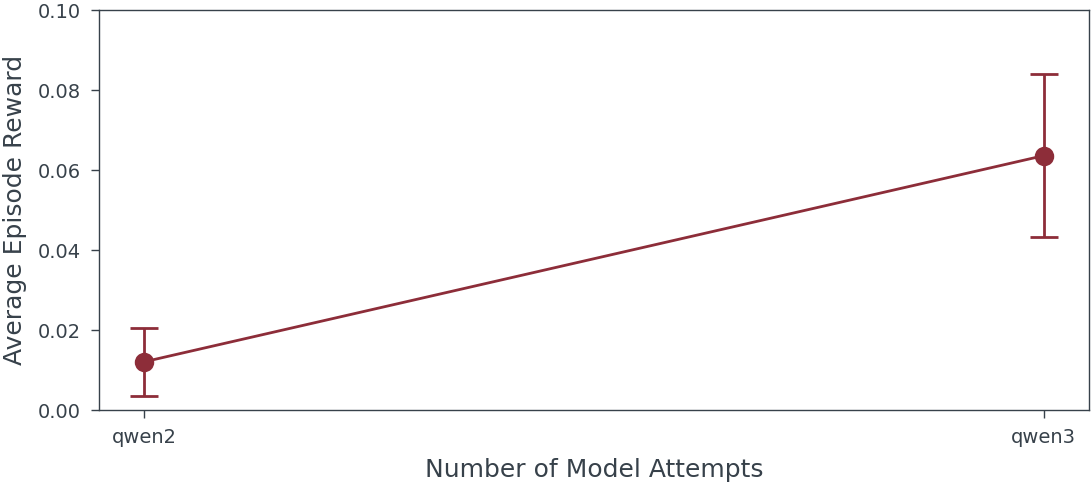

In [10]:
fig, ax = plt.subplots()
ax.errorbar(df_avg["model"], df_avg['mean'], yerr=df_avg['sem'], 
            marker='o', capsize=5, label='Average Reward')
ax.set_xlabel('Number of Model Attempts')
ax.set_xticks(df_avg["model"]) 
ax.set_ylabel('Average Episode Reward')
ax.set_ylim(0, 0.1)
plt.show()

In [11]:
df_lava = pd.read_csv(os.path.join(base_dir, "process_outputs", "baseline_results.csv"))
df_lava = df_lava[df_lava['environment'] == "lava"]
df_lava

,environment,approach,seed,episode,value
1600,lava,hardcoded,0,0,0.000000
1601,lava,hardcoded,0,1,0.000000
1602,lava,hardcoded,0,2,0.000000
1603,lava,hardcoded,0,3,0.681233
1604,lava,hardcoded,0,4,0.695135
...,...,...,...,...,...
1995,lava,random,9,5,0.000000
1996,lava,random,9,6,0.000000
1997,lava,random,9,7,0.000000
1998,lava,random,9,8,0.000000


In [12]:
df_lava_qwen3 = df[df['model'] == "qwen3"].copy()
df_lava_qwen3['environment'] = "lava"
df_lava_qwen3['approach'] = "ours_qwen3"
df_lava_qwen3 = df_lava_qwen3.drop(columns=['model'])
df_lava_qwen3 = df_lava_qwen3[['environment', 'approach', 'seed', 'episode', 'value']]
df_lava = pd.concat([df_lava, df_lava_qwen3], ignore_index=True)
df_lava

,environment,approach,seed,episode,value
0,lava,hardcoded,0,0,0.000000
1,lava,hardcoded,0,1,0.000000
2,lava,hardcoded,0,2,0.000000
3,lava,hardcoded,0,3,0.681233
4,lava,hardcoded,0,4,0.695135
...,...,...,...,...,...
495,lava,ours_qwen3,9,5,0.000000
496,lava,ours_qwen3,9,6,0.000000
497,lava,ours_qwen3,9,7,0.000000
498,lava,ours_qwen3,9,8,0.000000


In [13]:
# get the normalized values per environment and use that for plotting
df_normalized = df_lava.groupby(['environment', 'approach'])['value'].mean().reset_index()

# Get the hardcoded mean per environment
hardcoded_means = (
    df_normalized[df_normalized['approach'] == 'hardcoded']
    .set_index('environment')['value']        # Series: env -> mean(hardcoded)
)

df_plot = df_lava.groupby(['environment', 'approach'])['value'].agg(['mean', 'sem']).reset_index()
df_plot['mean_norm'] = df_plot['mean'] / df_plot['environment'].map(hardcoded_means)
df_plot['sem_norm'] = df_plot['sem'] / df_plot['environment'].map(hardcoded_means)
df_plot

,environment,approach,mean,sem,mean_norm,sem_norm
0,lava,hardcoded,0.214654,0.030456,1.000000,0.141884
1,lava,ours,0.012022,0.008510,0.056006,0.039647
2,lava,ours_qwen3,0.063590,0.020335,0.296243,0.094733
3,lava,random,0.000000,0.000000,0.000000,0.000000
4,lava,tabular,0.042602,0.016964,0.198467,0.079030


In [14]:
approaches = ["hardcoded", "ours", "tabular", "random", "ours_qwen3"]
df_plot["approach"] = pd.Categorical(df_plot["approach"], categories=approaches, ordered=True)
df_plot = df_plot.sort_values(["approach"])
df_plot

,environment,approach,mean,sem,mean_norm,sem_norm
0,lava,hardcoded,0.214654,0.030456,1.000000,0.141884
1,lava,ours,0.012022,0.008510,0.056006,0.039647
4,lava,tabular,0.042602,0.016964,0.198467,0.079030
3,lava,random,0.000000,0.000000,0.000000,0.000000
2,lava,ours_qwen3,0.063590,0.020335,0.296243,0.094733


(0.0, 1.15)

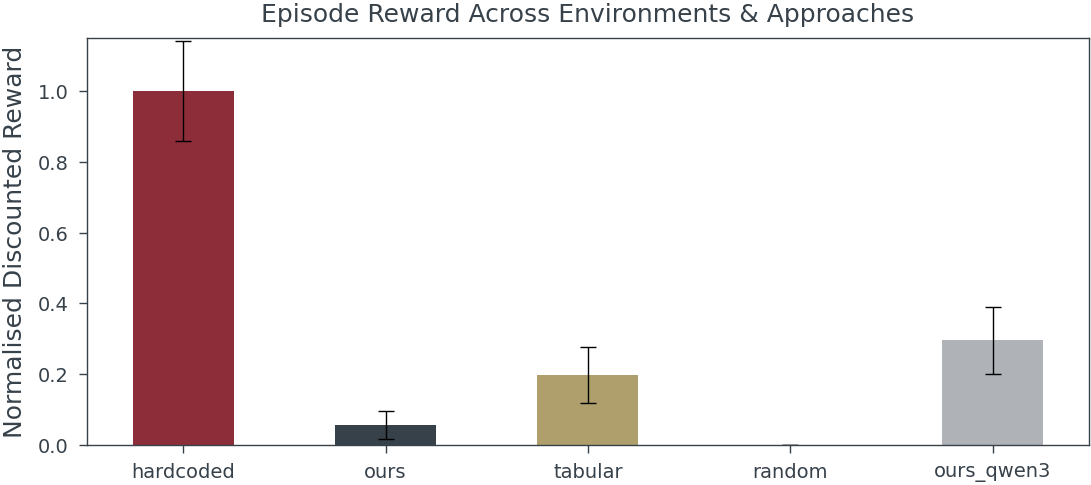

In [17]:
x = np.arange(len(approaches))
width = 0.5                       # bar width (tune for #approaches)

fig, ax = plt.subplots()

means = df_plot["mean_norm"].values
stds = df_plot["sem_norm"].values

ax.bar(
    x,
    means,
    width,
    yerr=stds,
    color=palettes.tue_plot,
    capsize=3,
    error_kw=dict(linewidth=0.5, capthick=0.5),
)

ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.set_ylabel("Normalised Discounted Reward")
ax.set_title("Episode Reward Across Environments & Approaches")
ax.set_ylim(0, 1.15)